In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("C:/Users/Dell/OneDrive/Desktop/EDA PROJECT/Raw/cleaned_day2.csv")
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,y,previously_contacted
0,58,Management,Married,Tertiary,No,2143.0,Yes,No,Unknown,5,May,261,1.0,-1,0,No,0
1,44,Technician,Single,Secondary,No,29.0,Yes,No,Unknown,5,May,151,1.0,-1,0,No,0
2,33,Entrepreneur,Married,Secondary,No,2.0,Yes,Yes,Unknown,5,May,76,1.0,-1,0,No,0
3,47,Blue-collar,Married,Secondary,No,1506.0,Yes,No,Unknown,5,May,92,1.0,-1,0,No,0
4,33,Blue-collar,Single,Secondary,No,1.0,No,No,Unknown,5,May,198,1.0,-1,0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,Technician,Married,Tertiary,No,825.0,No,No,Cellular,17,Nov,977,3.0,-1,0,Yes,0
45207,71,Retired,Divorced,Primary,No,1729.0,No,No,Cellular,17,Nov,456,2.0,-1,0,Yes,0
45208,72,Retired,Married,Secondary,No,3462.0,No,No,Cellular,17,Nov,1127,5.0,184,3,Yes,1
45209,57,Blue-collar,Married,Secondary,No,668.0,No,No,Telephone,17,Nov,508,4.0,-1,0,No,0


## Feature Engineering

**objective :** Create new variables that capture business value better than raw data.

- season_quarter : To capture fiscal trends.
- debt_score : To identify clients who are "debt-heavy"(housing loand + personal loan)
- previously_contacted : Flag pdays (-1/0,else/1) for cleaner predictor of familiarity
- age_group : Binning age into logical life stages
- is_high_value : Balance > Median AND Campaign < 3

In [34]:
#1.season_quarter
quarter = {
    'Jan': 'Q1', 'Feb': 'Q1', 'Mar': 'Q1',
    'Apr': 'Q2', 'May': 'Q2', 'Jun': 'Q2',
    'Jul': 'Q3', 'Aug': 'Q3', 'Sep': 'Q3',
    'Oct': 'Q4', 'Nov': 'Q4', 'Dec': 'Q4'
}
df["season_quarter"] = df["month"].map(quarter)


#2.dept_score
df['has_housing'] = df["housing"].apply(lambda x: 1 if x == "Yes" else 0) #flagging housing loan
df["has_personal"] = df["loan"].apply(lambda x: 1 if x == "Yes" else 0) #flagging personal loan
df["debt_score"] = df["has_housing"] + df["has_personal"] #if debt_score = 2 has heavy debt


#3.previously_contacted
df["previously_contacted"] #Already created during Day 2

#4.age_group
bins = [0, 30, 45, 60, 100]
labels = ['Young Adult', 'Middle Aged', 'Senior', 'Elderly']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)


#5.is_high_value
df["is_high_value"] = ((df["balance"]>df["balance"].median())&(df["campaign"]<=3)).astype(int)

## TIME-BASED ANALYSIS

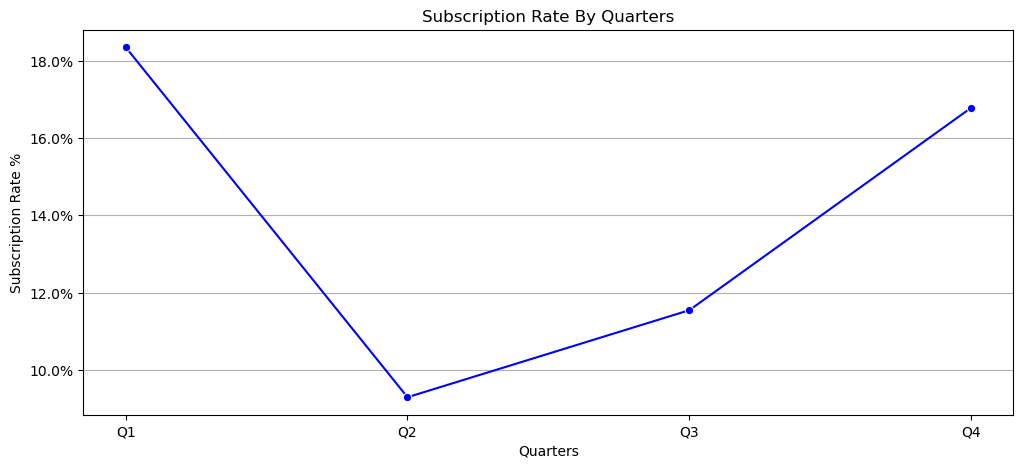

In [100]:
import matplotlib.ticker as mtick
plt.figure(figsize=(12,5))
order = ['Q1','Q2','Q3','Q4']
df['season_quarter'] = pd.Categorical(df['season_quarter'], categories=order, ordered=True)
sns.lineplot(data=df,x="season_quarter",y=df['y'].apply(lambda x: 1 if x == "Yes" else 0),
             marker='o',color='b',estimator='mean',errorbar=None)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(axis='y')
plt.ylabel("Subscription Rate %")
plt.xlabel("Quarters")
plt.title("Subscription Rate By Quarters")
plt.savefig("C:/Users/Dell/OneDrive/Desktop/EDA PROJECT/Reports/Fiqures/subscriptionByquarters.png",dpi=300,bbox_inches='tight')

### Insights & findings

- **The Trend:** Subscription rates follow a **U-Shape**—starting high in **Q1 (18%)**, crashing in **Q2/Q3 (~9-11%)**, and recovering in **Q4 (16%)**.
- **The Insight:** Seasonality is a major factor. Customers are twice as likely to buy Term Deposits in the **Winter months** (Jan-Mar, Oct-Dec) compared to the Summer.
- **The Action:** Stop "spraying and praying" in May/June. **Shift your marketing budget to Q1 and Q4 to maximize ROI**.

# STATISTICAL HYPOTHESIS TESTING

We use a significance level of $\alpha = 0.05$.

1. **T-Test:** Do customers who subscribe (Yes) have a higher Account Balance than those who don't (No)?
2. **Chi-square:** Is a customer's Job Role related to whether they subscribe to the term deposit?
3. **ANOVA:** Does Marital Status (Married, Single, Divorced) impact the number of contacts (campaign) needed?

In [101]:
#T-Test
from scipy.stats import ttest_ind

subscribers = df[df['y'] == 'Yes']['balance']
non_subscribers = df[df['y'] == 'No']['balance']

stat, p_val = ttest_ind(subscribers, non_subscribers, equal_var=False)

print(f"P-Value: {p_val}")
print(f"Avg Balance (Yes): {subscribers.mean():.2f}")
print(f"Avg Balance (No):  {non_subscribers.mean():.2f}")

if p_val < 0.05:
    print("Result: Significant Difference. Wealthier people behave differently.")
else:
    print("Result: No significant difference in balance.")

P-Value: 2.2982176049487414e-76
Avg Balance (Yes): 1234.13
Avg Balance (No):  893.91
Result: Significant Difference. Wealthier people behave differently.


In [102]:
#Chi-square

from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['job'], df['y'])
chi2, p_val, dof, expected = chi2_contingency(contingency_table)

print(f"P-Value: {p_val}")
if p_val < 0.05:
    print("Result: Significant Relationship. A person's Job affects their decision.")
else:
    print("Result: No Relationship found.")

P-Value: 5.575427995540736e-172
Result: Significant Relationship. A person's Job affects their decision.


In [103]:
#ANOVA

from scipy.stats import f_oneway

group_married = df[df['marital'] == 'Married']['campaign']
group_single = df[df['marital'] == 'Single']['campaign']
group_divorced = df[df['marital'] == 'Divorced']['campaign']

stat, p_val = f_oneway(group_married, group_single, group_divorced)

print(f"P-Value: {p_val}")
if p_val < 0.05:
    print("Result: Significant Difference. Marital status affects how many calls are needed.")
else:
    print("Result: No difference. Everyone requires the same amount of effort.")

P-Value: 5.0582437832947814e-24
Result: Significant Difference. Marital status affects how many calls are needed.


#  Statistical Hypothesis Testing: Findings & Insights

**1. T-Test: Balance vs. Subscription**
* **Hypothesis:** Do subscribers have a higher average balance than non-subscribers?
* **Result:** <font color='green'>**Significant Difference**</font> (P-Value $\approx$ 0)
    * **Avg Balance (Subscribers):** \$1,234
    * **Avg Balance (Non-Subscribers):** \$894
* **Insight:** Wealth is a major predictor. Subscribers have **38% more funds** on average.
* **Action:** **"Follow the Money."** Prioritize calling customers with a balance **above \$1,000**. Assign these high-value leads to senior agents.

---

**2. Chi-Square Test: Job Role vs. Subscription**
* **Hypothesis:** Is a customer's job title related to their likelihood to subscribe?
* **Result:** <font color='green'>**Significant Relationship**</font> (P-Value $\approx$ 0)
* **Insight:** Occupation strongly dictates financial behavior. As seen in EDA, **Students** and **Retirees** convert at higher rates, while Blue-collar workers convert less.
* **Action:** **Script Segmentation.** Do not use a generic script.
    * *Students/Retired:* Pitch "Safety & Future Savings."
    * *Management:* Pitch "Liquidity & Diversification."

---

**3. ANOVA: Marital Status vs. Call Effort (Campaign)**
* **Hypothesis:** Does marital status affect the number of calls needed to close (or lose) a deal?
* **Result:** <font color='green'>**Significant Difference**</font> (P-Value < 0.05)
    * **Married:** 2.45 calls (Highest Effort)
    * **Single:** 2.29 calls (Lowest Effort)
* **Insight:** **"Married customers are harder to convince."** They require ~7% more effort/calls, likely because financial decisions often require spousal consultation. Single people decide faster.
* **Action:** **Optimize Call Schedules.**
    * *Single Leads:* Close them fast (within 2 calls).
    * *Married Leads:* Be patient. Schedule follow-ups in the evening to allow for spousal discussion.

# Executive Summary: Strategic Insights & Recommendations

Based on the Exploratory Data Analysis (EDA) and Statistical Hypothesis Testing,Verifiend & identified the key drivers for Term Deposit subscriptions.

### 1.  The "Golden" Customer Profile (Who to Call)
Our statistical tests confirm that **Wealth** and **Life Stage** are the strongest predictors of success.
* **Financials:** Focus on customers with a **bank balance > \$1,000**.
    * *Evidence:* T-Test showed subscribers have ~38% higher average balances ($1,234 vs $894).
* **Debt Status:** Prioritize customers **without a housing loan**.
    * *Evidence:* Debt-free customers are **2x more likely** to subscribe.
* **Demographics:** Target **Students** and **Retirees**.
    * *Evidence:* These groups have the highest conversion rates, likely due to a need for low-risk savings.
* **Marital Status:** Be aware that **Married** customers take longer to convert.
    * *Evidence:* ANOVA results show married clients require ~7% more calls/effort than single clients.

### 2.  The "Winning" Season (When to Call)
* **Winter Opportunity (Q1 & Q4):** The highest subscription rates occur in **Jan-Mar** and **Oct-Dec**.
    * *Insight:* Customers are driven by "New Year Resolutions" or "Year-End Financial Planning."
* **Summer Trap (Q2 & Q3):** We currently expend the most effort in **May**, but it yields the lowest success rate.
    * *Action:* Stop "spraying and praying" in the summer. Shift marketing budget to Q1/Q4.

### 3.  Operational Efficiency (How to Call)
* **The "3-Strike" Rule:** The average successful sale takes **~2 calls**.
    * *Action:* Stop calling a lead after 3 failed attempts to avoid diminishing returns.


---


In [104]:
df.to_csv("C:/Users/Dell/OneDrive/Desktop/EDA PROJECT/Raw/final_cleaned_day4.csv", index=False)